# cellAdmix Xenium Example: Pancreas Membrane and Bridge Scoring

## Overview

This notebook illustrates a cellAdmix workflow on a Xenium pancreas
dataset with membrane staining. The example starts from a Xenium output
bundle, a simple cell-type annotation, and a coarse regional annotation.
The core fit uses default cellAdmix settings: weighted least-squares
(`ls_nmf`) NMF, automatic rank from the number of annotated cell types,
an automatically resolved neighborhood size, multiple NMF starts, and
gene-loading molecule scoring.

At a high level, the workflow is:

In [ ]:
ds <- cellAdmix(bundle_dir, output_dir = output_dir, annotation = cell_annotation)
fit <- ds$fit()

membrane_score <- fit$score_membrane()
membrane_rules <- membrane_score$rules()
membrane_correction <- membrane_score$correct(rules = membrane_rules)

bridge_score <- fit$score_bridge()
bridge_rules <- bridge_score$rules()
bridge_correction <- bridge_score$correct(rules = bridge_rules)

The constructor records the Xenium bundle location, validates the input
configuration, and stores lightweight cell-level metadata. It does not
load all molecules into R memory. The computational work starts with
`fit()`, followed by one or more scoring methods that identify
source-target admixture patterns and produce correction rules.

## Inputs

Download the Xenium output bundle from the original [10x Genomics
dataset
page](https://www.10xgenomics.com/datasets/ffpe-human-pancreas-with-xenium-multimodal-cell-segmentation-1-standard)
and expand it into a local folder named `data`. The bundle zip can be
downloaded directly with:

In [ ]:
curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Pancreas_FFPE/Xenium_V1_human_Pancreas_FFPE_outs.zip

Also create a folder named `annotations` and download the example
annotation files from
<http://pklab.org/peterk/cellAdmix/examples/pancreas_377/annotations>.
The two files used below are `annotations/annotation.csv.gz` and
`annotations/domain_annotation.csv.gz`. Base R can read these
gzip-compressed CSV files directly.

The supplied cell annotation and regional-domain segmentation files are
quick-and-dirty labels generated only for this illustration. They are
not curated biological ground truth, and they are probably wrong in
places. In a real analysis, use your own cell-type annotations and
tissue-region definitions.

The output directory `out` stores reusable cellAdmix caches, fit
outputs, scores, and corrected runs.

In [ ]:
bundle_dir <- "data"
output_dir <- "out"
annotation_file <- file.path("annotations", "annotation.csv.gz")
domain_file <- file.path("annotations", "domain_annotation.csv.gz")

annotation <- read.csv(annotation_file, stringsAsFactors = FALSE)
domain_annotation <- read.csv(domain_file, stringsAsFactors = FALSE)

table(annotation$merged_annotation)


Ductal/tumor epithelial               Endocrine             Endothelial 
                  29986                    2212                    7026 
    Exocrine epithelial        Fibroblast / CAF                  Immune 
                  36329                   28366                   19251 
       Mural / pericyte 
                   2553 


adjacent_normal      transition           tumor 
          37909           38853           48961 

The cell-type annotation is passed to `cellAdmix()` as a named vector.
The regional-domain table is kept in R memory because it is only used
later for plots and diagnostic DE comparisons, not for factor fitting or
scoring.

In [ ]:
cell_annotation <- setNames(annotation$merged_annotation, annotation$cell_id)

ds <- cellAdmix(bundle_dir, output_dir = output_dir, annotation = cell_annotation)

ds

cellAdmix dataset
  format: xenium 
  output cache: configured
  threads: 10 
  molecules: transcripts.parquet 
  cells: cells.parquet 
  annotation:manual (125723 cells, 7 labels)

## Fit Factors

`ds$fit()` constructs molecule-centered neighborhood composition
vectors, fits NMF factors, projects/smooths molecule factor assignments,
and summarizes the result at cell level. The rank is automatically
derived from the number of cell types in the active annotation.

In [ ]:
fit <- ds$fit(verbose = TRUE)

Reusing cached run fit_manual_rank9_ls_nmf (parameters match)

cellAdmix fit
  run: fit_manual_rank9_ls_nmf 
  annotation: manual 
  rank: 9 
  NMF: ls_nmf 
  molecule scoring: gene_loadings 
  cells: 140335 
  transcripts: 6186500 

Top gene loadings are the first-pass interpretation of each factor.

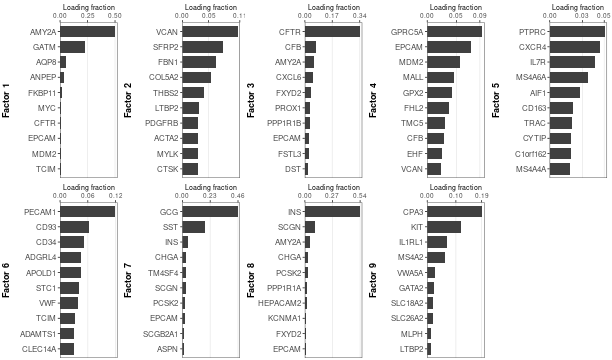

In [ ]:
fit$plot_loadings()

The stability plot shows whether high-importance factors are
reproducible across independent NMF restarts (matched gene-ownership
correlation: near zero for unrelated factors, above 0.3 for reproducibly
re-found ones). Factor importance (the x-axis, echoed by dot size) is
the share of all assigned molecules that carry the factor’s label, so
large dots mark factors that dominate the tissue-wide signal.

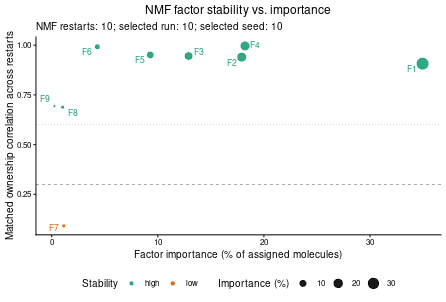

In [ ]:
fit$plot_stability()

## Factor Source Prior

Top loadings are useful, but source calls should emphasize genes that
actually distinguish annotated cell types. `score_factor_sources()`
builds pseudobulk cell-type profiles from the original counts, estimates
one-versus-rest cell-type marker weights, and compares each NMF factor
against those weighted marker signatures. This is a diagnostic source
prior only; the membrane and bridge scores below are still run
independently.

In [ ]:
original_counts <- fit$counts()
factor_source_score <- fit$score_factor_sources(counts = original_counts)

factor_source_score$annotation()

   factor factor_label        source_cell_type      score     margin called
4       1           F1     Exocrine epithelial 0.54857875 0.54280794   TRUE
12      2           F2        Fibroblast / CAF 0.80145575 0.64336452   TRUE
15      3           F3                    <NA> 0.08549077 0.01626588  FALSE
22      4           F4 Ductal/tumor epithelial 0.64640738 0.59529309   TRUE
34      5           F5                  Immune 0.71838431 0.60879528   TRUE
38      6           F6             Endothelial 0.66037987 0.56127174   TRUE
44      7           F7               Endocrine 0.51753172 0.50978780   TRUE
51      8           F8               Endocrine 0.46821084 0.43534217   TRUE
62      9           F9                    <NA> 0.07604785 0.02878332  FALSE

In this table, `score` is the marker-weighted similarity between a
factor and the best matching cell type. `margin` is the best score minus
the second-best score for that factor; larger margins indicate more
specific source evidence. `called` indicates whether the best cell type
passed both the score and margin thresholds used for source-prior
annotation.

The heatmap shows marker-weighted gene-content evidence for each factor
and cell type. The `S` marker identifies the best gene-content source
call for each factor.

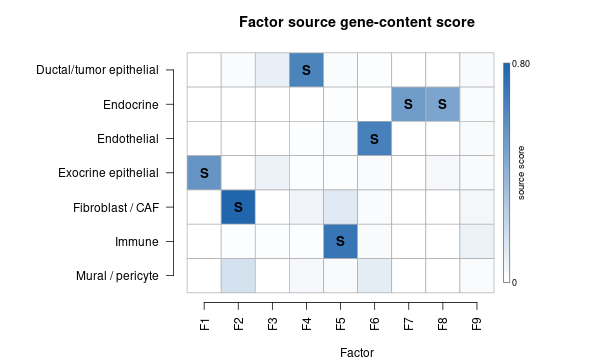

In [ ]:
factor_source_score$plot_heatmap()

The next plot shows the cell-type marker genes that most strongly
support each factor’s best source call.

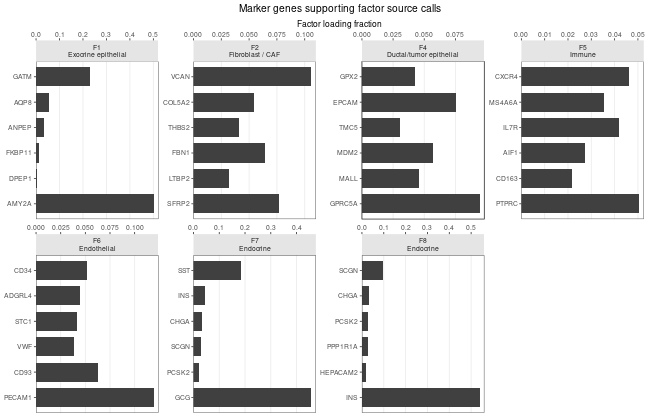

In [ ]:
factor_source_score$plot_top_genes()

## Tissue Context

The cell-type and domain plots below are side visualizations. To prepare
them, we merge the cellAdmix cell-level factor summaries with the
supplied cell-type and regional-domain annotations.

In [ ]:
cell_factors <- fit$cell_factors()
cell_spatial <- merge(cell_factors,
  annotation[, c("cell_id", "merged_annotation", "cluster_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial <- merge(cell_spatial,
  domain_annotation[, c("cell_id", "domain_label", "domain_fine_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial$domain_label <- factor(cell_spatial$domain_label,
  levels = c("adjacent_normal", "transition", "tumor"))

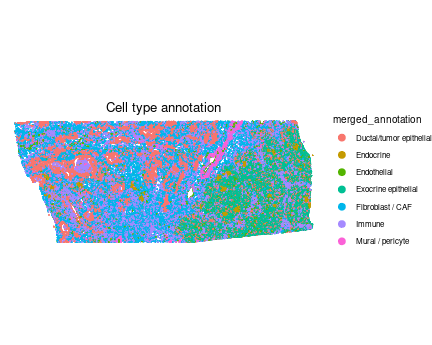

In [ ]:
celladmix_plot_spatial(cell_spatial, color_by = "merged_annotation") +
  ggtitle("Cell type annotation")

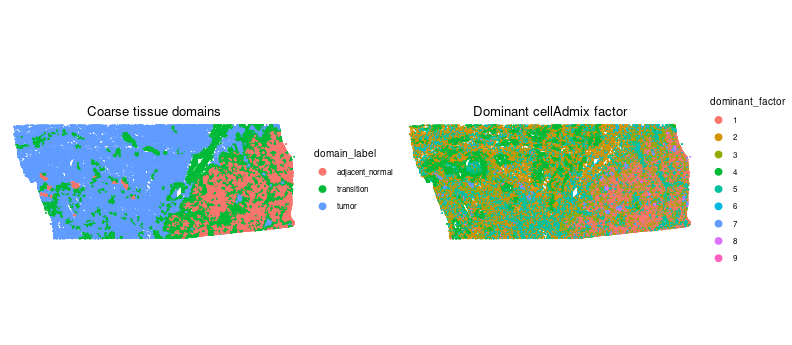

In [ ]:
cowplot::plot_grid(plotlist = list(
  celladmix_plot_spatial(cell_spatial, color_by = "domain_label") +
    ggtitle("Coarse tissue domains"),
  celladmix_plot_spatial(cell_spatial, color_by = "dominant_factor") +
    ggtitle("Dominant cellAdmix factor")
), ncol = 2, align = "hv", axis = "tblr")

## Diagnostic Setup

Scoring and correction below are run for all annotated cell types. To
keep the diagnostic plots readable, we focus the downstream DE and
example-cell panels on two illustrative cell types: endothelial and
immune cells. These choices are only for visualization; they do not
restrict the cleanup rules.

The marker genes below are used to highlight likely admixture sources in
the diagnostic plots: ductal/tumor epithelial cells and
endocrine/exocrine epithelium.

In [ ]:
diagnostic_cell_types <- c("Endothelial", "Immune")

ductal_tumor_markers <- c("GPRC5A", "MALL", "FHL2", "EPCAM", "GPX2", "MET",
  "SERPINB3", "KRT7")
endocrine_exocrine_markers <- c("AMY2A", "AQP8", "ANPEP", "CFTR", "INS",
  "GCG", "SST", "CHGA", "SCGN")
source_marker_sets <- list(
  "ductal/tumor source" = ductal_tumor_markers,
  "endocrine/exocrine source" = endocrine_exocrine_markers
)

We then run a baseline DE comparison between tumor and adjacent-normal
domains for the two diagnostic cell types using the original counts
collected above. These DE results are only used for the illustrative
before/after cleanup plots later in the notebook.

In [ ]:
diagnostic_de_original <- celladmix_de_by_group(original_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor", "adjacent_normal"))

These baseline volcano plots show tumor-domain versus
adjacent-normal-domain differences before any molecule removal. Positive
logFC means higher expression in tumor-domain target cells.

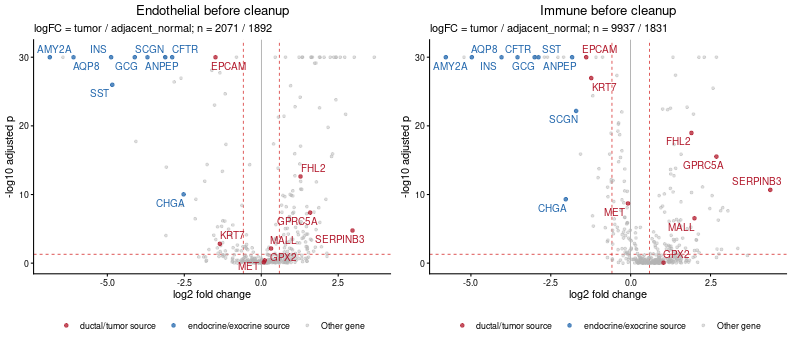

In [ ]:
baseline_volcano_plots <- lapply(diagnostic_cell_types, function(target_type) {
  de <- diagnostic_de_original[[target_type]]
  celladmix_plot_volcano(de, markers = source_marker_sets,
    title = paste(target_type, "before cleanup"),
    subtitle = sprintf("logFC = tumor / adjacent_normal; n = %d / %d",
      unique(de$n_group_a), unique(de$n_group_b)))
})
cowplot::plot_grid(plotlist = baseline_volcano_plots,
  ncol = length(baseline_volcano_plots), align = "hv", axis = "tblr")

## Membrane Scoring

Membrane scoring asks whether target-cell molecules assigned to a factor
are enriched along membrane-stain paths facing a candidate source cell
type. The score summaries are thresholded at `p_thresh`; here we use a
permissive threshold because this notebook is meant to compare candidate
cleanup rules.

In [ ]:
p_thresh <- 0.1
score_pairs_width <- 9.6
score_pairs_height <- max(6, ceiling(fit$rank / 2) * 4.9)

First, run the membrane scoring procedure. The returned `membrane_score`
object stores the raw pair-level and summarized evidence; it does not
modify molecules.

In [ ]:
membrane_score <- fit$score_membrane()

Next, convert score summaries into factor annotations. For each factor,
this identifies the most plausible source cell type and target cell
types with significant membrane-supported admixture evidence.

In [ ]:
membrane_annotation <- membrane_score$annotation(p_thresh = p_thresh)

Finally, convert those annotation calls into correction rules. Each row
says that molecules assigned to a given factor should be removed from a
target cell type; the source cell type is retained as an interpretation
of the likely origin. A native-factor check runs on each rule by
default: rules whose factor persists in target cells with no source-type
neighbors are flagged (`keep = FALSE`) as likely native expression and
skipped by correction.

In [ ]:
membrane_rules <- membrane_score$rules(p_thresh = p_thresh)

head(membrane_rules[, c("factor", "source_cell_type", "target_cell_type",
  "p_value", "keep", "native_check")])

  factor    source_cell_type        target_cell_type      p_value keep
1      1 Exocrine epithelial               Endocrine 5.164693e-06 TRUE
2      1 Exocrine epithelial             Endothelial 8.782525e-07 TRUE
3      1 Exocrine epithelial        Fibroblast / CAF 6.040547e-06 TRUE
4      1 Exocrine epithelial                  Immune 1.880801e-04 TRUE
5      1 Exocrine epithelial        Mural / pericyte 4.845720e-02 TRUE
6      2    Fibroblast / CAF Ductal/tumor epithelial 6.952872e-04 TRUE
  native_check
1         pass
2         pass
3         pass
4         pass
5         pass
6         pass

The heatmap summarizes factor-by-cell-type evidence. Color intensity
shows the strongest membrane-supported target evidence for each factor
and cell type; plot symbols mark inferred source and cleanup target
calls. With the gene-content source prior overlaid, `S` marks the
membrane/spatial source, `G` marks the gene-content source, `SG` marks
agreement, separate `S` and `G` labels in the same factor column
indicate a source conflict, and `*` marks a cleanup target.

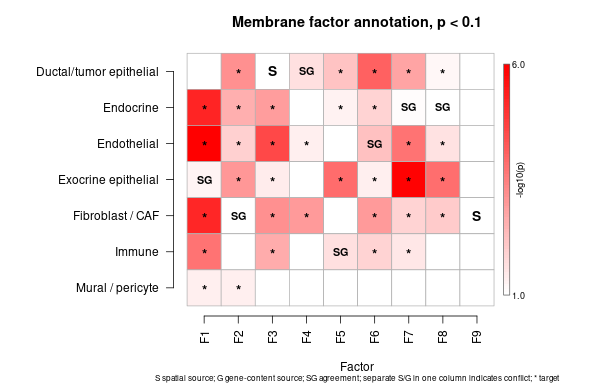

In [ ]:
membrane_score$plot_heatmap(p_thresh = p_thresh,
  source_prior = factor_source_score)

The pair plots show the same membrane evidence one factor at a time.
Rows are factors, columns are candidate target cell types, and the top
margin summarizes which source cell types best explain each factor. This
view is useful for checking whether a correction rule has a plausible
source and target pattern.

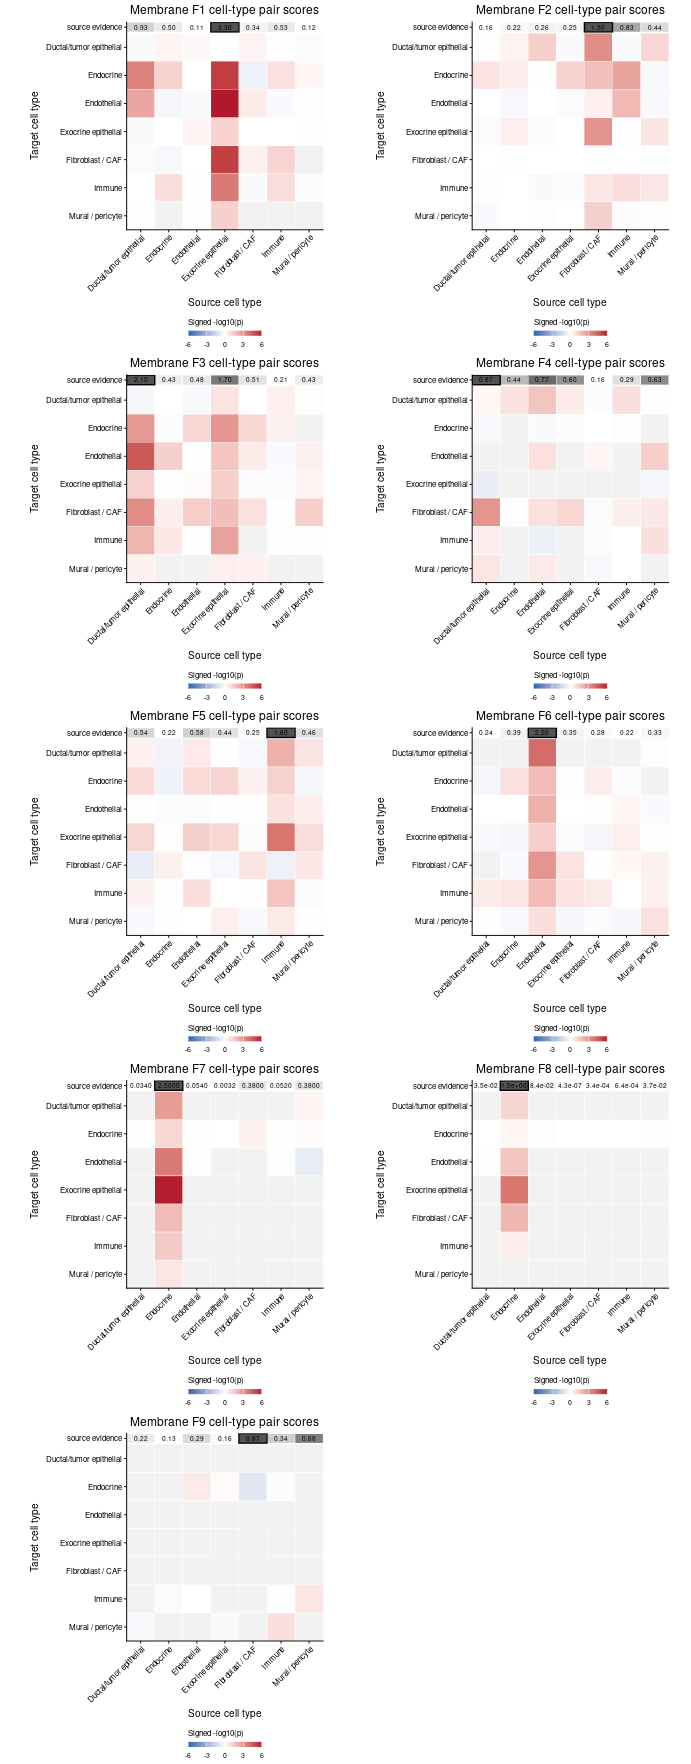

In [ ]:
membrane_score$plot_pairs()

### Example Cells

Next, we render a few target-cell examples for the diagnostic cell
types. The cell selection uses the membrane score to find cells with
strong rule-supported admixture-factor evidence. The molecule colors
show post-smoothing factor labels: native factors in blue, the top
putative admixture factor in red, and other non-native factors in
orange. Marker-gene molecules are shown with the same color coding, but
are drawn slightly larger.

The DAPI/membrane stain backgrounds, cell boundaries, and cell-type
contour coloring are discovered automatically from the Xenium bundle;
stain pixel data are read lazily as small crops around each selected
cell. Pass `stains = NULL` or `color_cell_types = FALSE` to simplify the
panels, or plot specific cells with `plot_examples(cells = c(...))`.

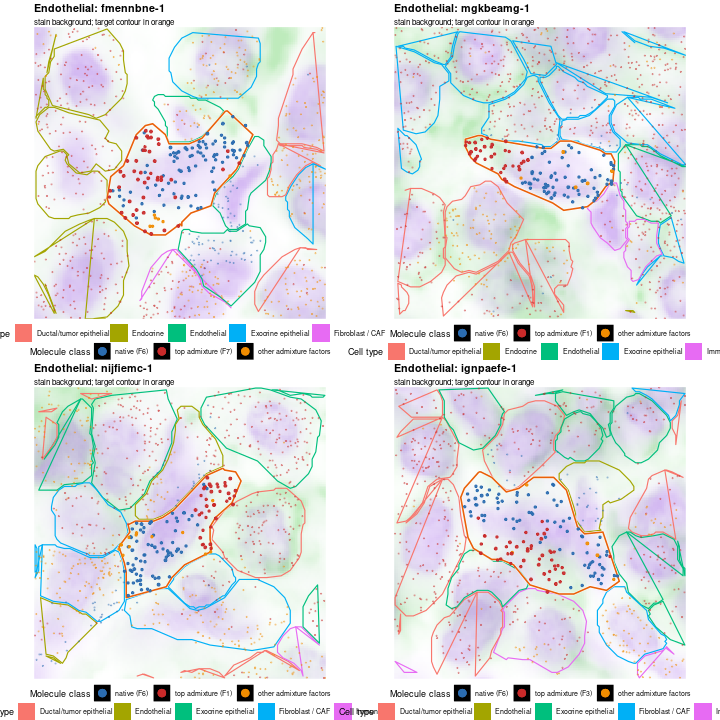

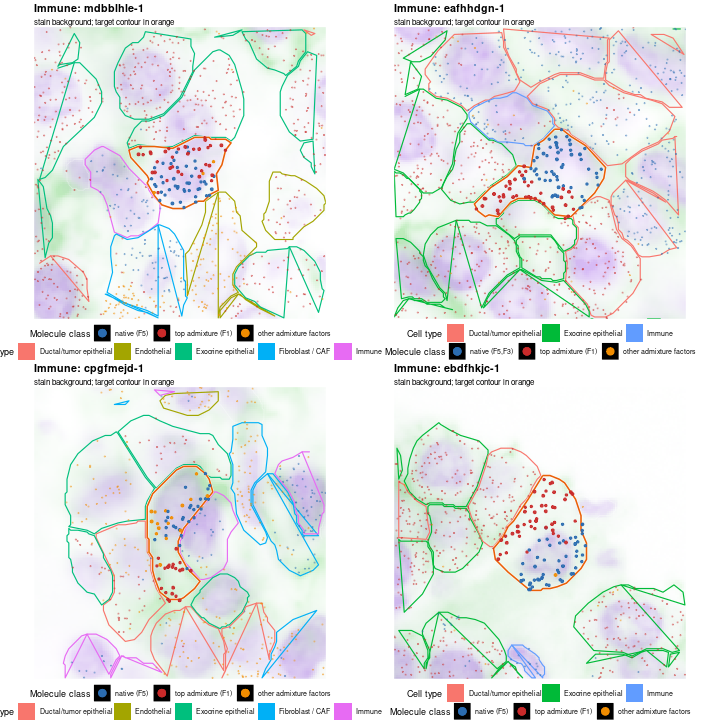

In [ ]:
example_cells <- membrane_score$examples(rules = membrane_rules,
  score_annotation = membrane_annotation, cell_data = cell_spatial,
  targets = diagnostic_cell_types, n_per_target = 4)

for (cell_type in diagnostic_cell_types) {
  type_examples <- example_cells[example_cells$target_cell_type == cell_type, , drop = FALSE]
  print(membrane_score$plot_examples(type_examples,
    score_annotation = membrane_annotation, cell_data = cell_spatial,
    markers = unique(unlist(source_marker_sets)), ncol = 2))
}

Specific cells can also be plotted directly by ID with `cells =`,
whether or not they would have been auto-selected — useful for following
up on cells noticed in other views.

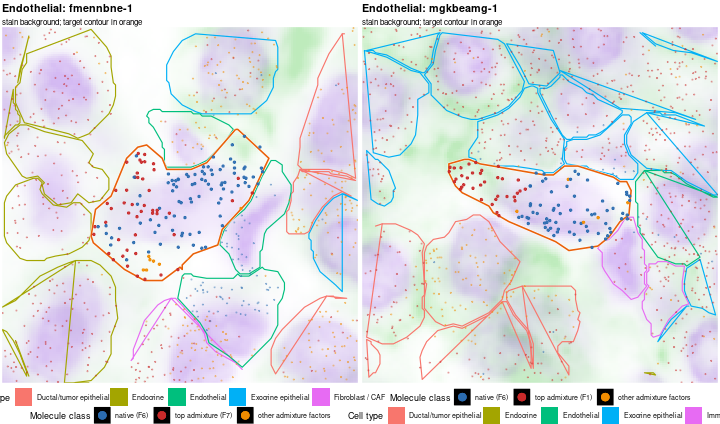

In [ ]:
print(membrane_score$plot_examples(
  cells = as.character(example_cells$target_cell[1:2]),
  score_annotation = membrane_annotation, cell_data = cell_spatial, ncol = 2))

### Membrane Cleanup Diagnostics

The correction step below applies all membrane-derived rules across all
annotated cell types. This creates a corrected run and then collects the
corrected cell-by-gene count matrix that will be used for downstream
diagnostics.

In [ ]:
membrane_correction <- membrane_score$correct(rules = membrane_rules,
  name = "membrane_clean")
membrane_counts <- membrane_correction$counts()

membrane_correction$summary()

                cell_type n_cells n_modified_cells fraction_cells_modified
1                     all  140335            72420               0.5160509
2 Ductal/tumor epithelial   29986            17256               0.5754686
3               Endocrine    2212             1719               0.7771248
4             Endothelial    7026             5257               0.7482209
5     Exocrine epithelial   36329            26577               0.7315643
6        Fibroblast / CAF   28366            13990               0.4931961
7                  Immune   19251             7324               0.3804478
8        Mural / pericyte    2553              297               0.1163337
9                 unknown   14612                0               0.0000000
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1          6186500         5502823            683677                 0.11051111
2          1918375         1843339             75036                 0.03911435
3         

The next step is illustrative: repeat the same
tumor-versus-adjacent-normal DE comparison on the corrected counts,
limited to the two diagnostic cell types defined above. This lets us
inspect how membrane-based cleanup changes the example DE signal.

In [ ]:
membrane_de <- celladmix_de_by_group(membrane_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor", "adjacent_normal"))

This boxplot summarizes the number and fraction of molecules removed per
cell. It is a coarse sanity check: very large shifts indicate aggressive
cleanup, while near-zero shifts indicate that few rules applied to the
dataset.

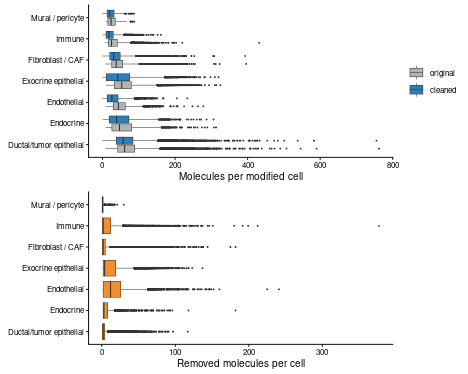

In [ ]:
membrane_correction$plot_removed_molecules()

The marker-expression plots compare source-marker expression in the
original and corrected count matrices. Here they are restricted to the
two diagnostic target cell types, so the plot illustrates cleanup impact
rather than defining which cell types were corrected.

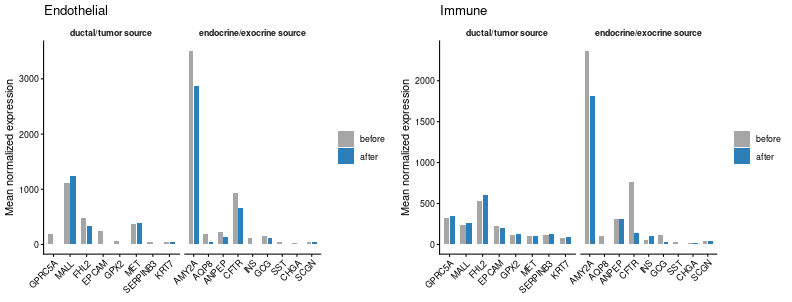

In [ ]:
plots <- lapply(diagnostic_cell_types, function(cell_type) {
  cells <- cell_spatial$cell_id[cell_spatial$merged_annotation == cell_type]
  celladmix_plot_marker_expression(original_counts, membrane_counts,
    cells = cells, markers = source_marker_sets) +
    ggplot2::ggtitle(cell_type)
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

The volcano plots show the same tumor-versus-adjacent-normal DE
comparison before and after cleanup. The goal is to check whether
highlighted source-marker genes become less prominent after removing
putative admixture molecules.

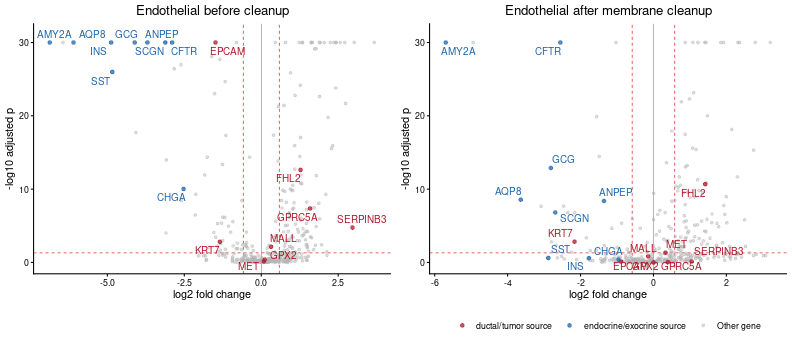

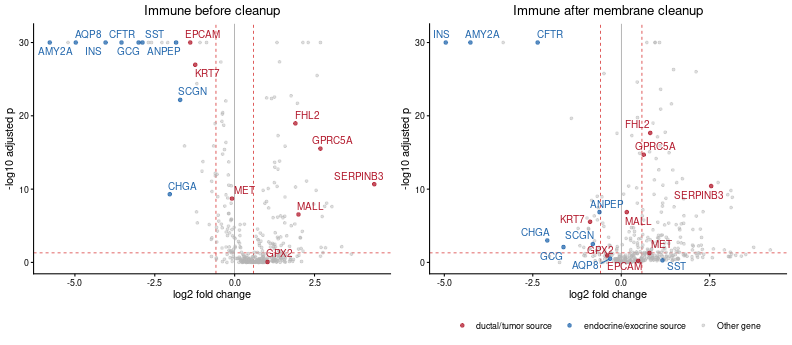

In [ ]:
for (target_type in diagnostic_cell_types) {
  p_before <- celladmix_plot_volcano(diagnostic_de_original[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "before cleanup")) +
    ggplot2::theme(legend.position = "none")
  p_after <- celladmix_plot_volcano(membrane_de[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "after membrane cleanup"))
  print(cowplot::plot_grid(plotlist = list(p_before, p_after),
    ncol = 2, align = "hv", axis = "tblr"))
}

The scatter plots below compare each gene’s adjusted DE significance
before and after cleanup. Genes below the diagonal are less significant
after correction; highlighted markers show whether expected source
signatures are reduced in the diagnostic target cell types.

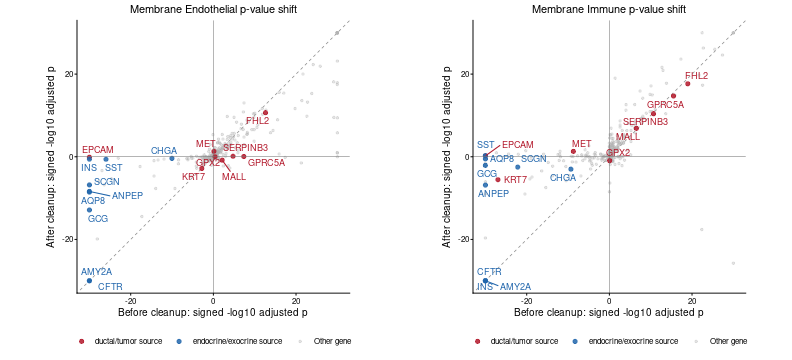

In [ ]:
plots <- lapply(diagnostic_cell_types, function(target_type) {
  celladmix_plot_de_shift(diagnostic_de_original[[target_type]], membrane_de[[target_type]],
    markers = source_marker_sets, title = paste("Membrane", target_type, "p-value shift"))
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

## Bridge Scoring

Bridge scoring uses molecule adjacency across candidate cell pairs
rather than the stain image. It is useful when a source cell is visible
and physically adjacent to target molecules.

In [ ]:
bridge_score <- fit$score_bridge()
bridge_annotation <- bridge_score$annotation(p_thresh = p_thresh)
bridge_rules <- bridge_score$rules(p_thresh = p_thresh)

head(bridge_rules[, c("factor", "source_cell_type", "target_cell_type", "p_value")])

  factor    source_cell_type        target_cell_type      p_value
1      1 Exocrine epithelial Ductal/tumor epithelial 5.626363e-02
2      1 Exocrine epithelial        Mural / pericyte 3.345508e-02
3      2    Fibroblast / CAF Ductal/tumor epithelial 1.049775e-10
4      2    Fibroblast / CAF               Endocrine 1.219512e-02
5      2    Fibroblast / CAF             Endothelial 2.762706e-03
6      2    Fibroblast / CAF     Exocrine epithelial 1.756719e-02

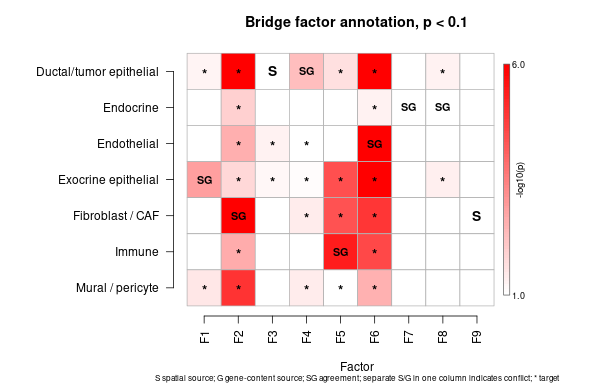

In [ ]:
bridge_score$plot_heatmap(p_thresh = p_thresh,
  source_prior = factor_source_score)

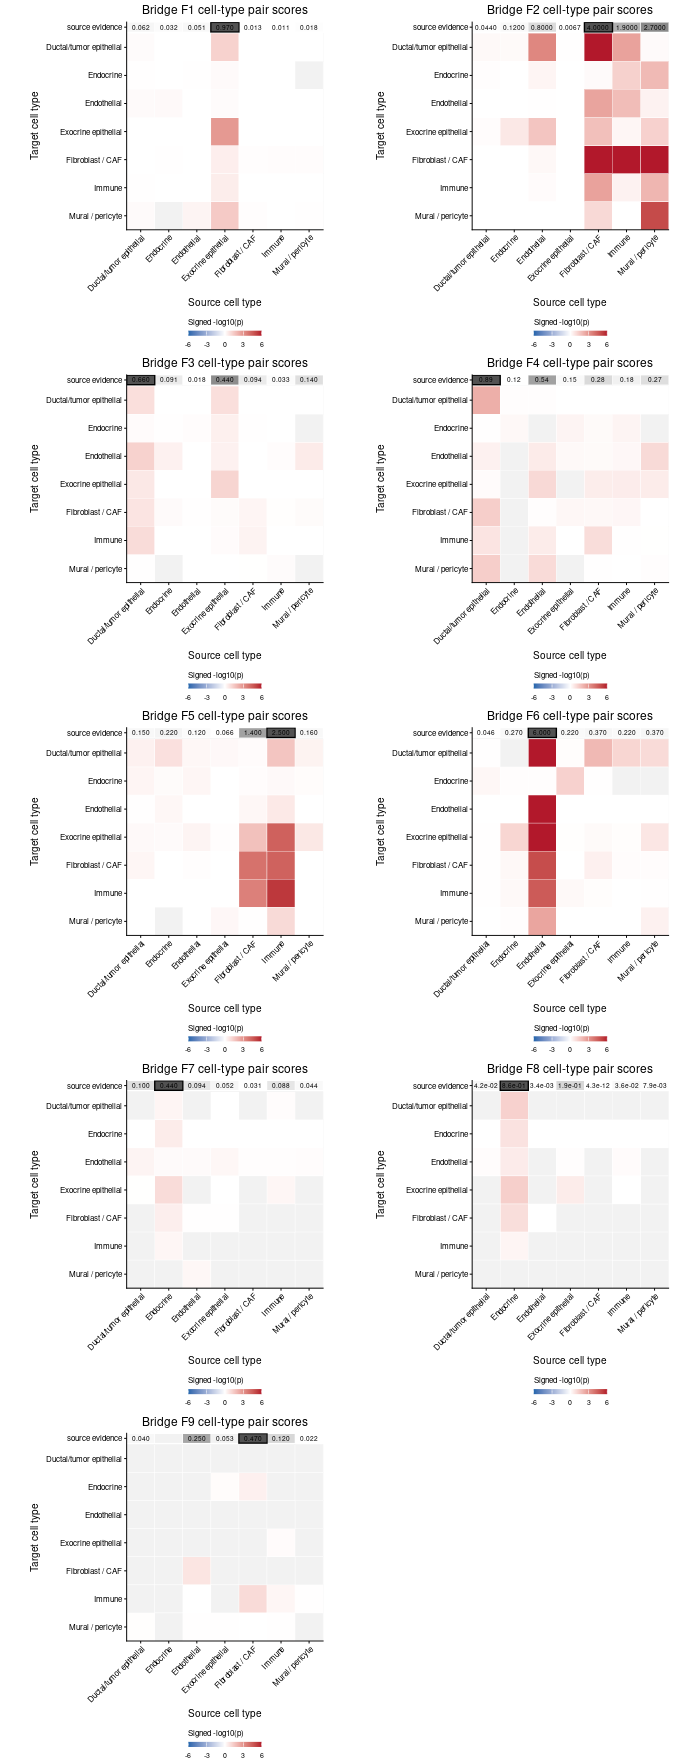

In [ ]:
bridge_score$plot_pairs()

The correction step below applies all bridge-derived rules across all
annotated cell types. As above, the downstream diagnostic plots focus
only on the illustrative endothelial and immune target cells.

In [ ]:
bridge_correction <- bridge_score$correct(rules = bridge_rules,
  name = "bridge_clean")
bridge_counts <- bridge_correction$counts()
bridge_de <- celladmix_de_by_group(bridge_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor", "adjacent_normal"))

bridge_correction$summary()

                cell_type n_cells n_modified_cells fraction_cells_modified
1                     all  140335            72749               0.5183953
2 Ductal/tumor epithelial   29986            20196               0.6735143
3               Endocrine    2212             1127               0.5094937
4             Endothelial    7026             4410               0.6276687
5     Exocrine epithelial   36329            27749               0.7638250
6        Fibroblast / CAF   28366             9373               0.3304308
7                  Immune   19251             8648               0.4492234
8        Mural / pericyte    2553             1246               0.4880533
9                 unknown   14612                0               0.0000000
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1          6186500         5321909            864591                 0.13975447
2          1918375         1570388            347987                 0.18139676
3         

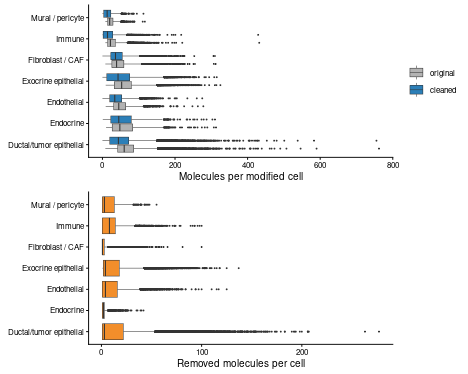

In [ ]:
bridge_correction$plot_removed_molecules()

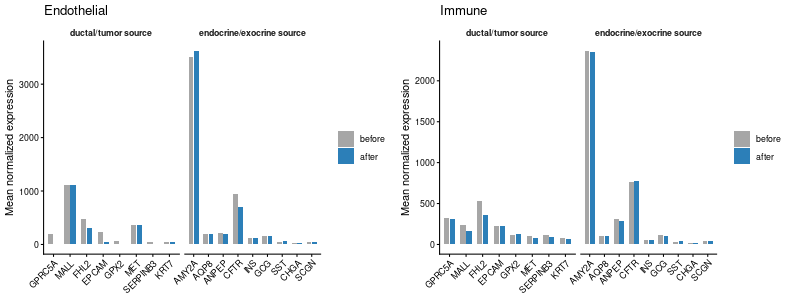

In [ ]:
plots <- lapply(diagnostic_cell_types, function(cell_type) {
  cells <- cell_spatial$cell_id[cell_spatial$merged_annotation == cell_type]
  celladmix_plot_marker_expression(original_counts, bridge_counts,
    cells = cells, markers = source_marker_sets) +
    ggplot2::ggtitle(cell_type)
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

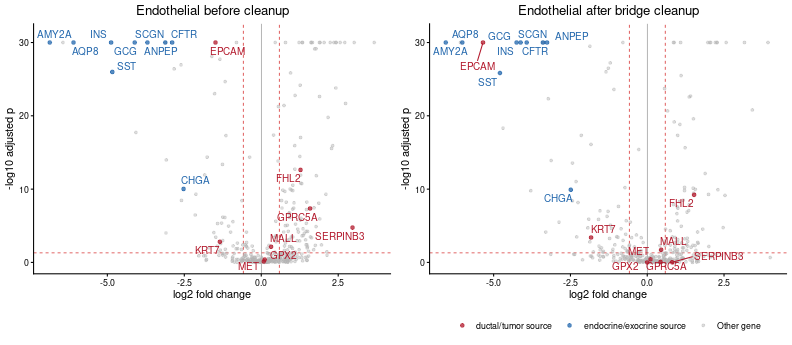

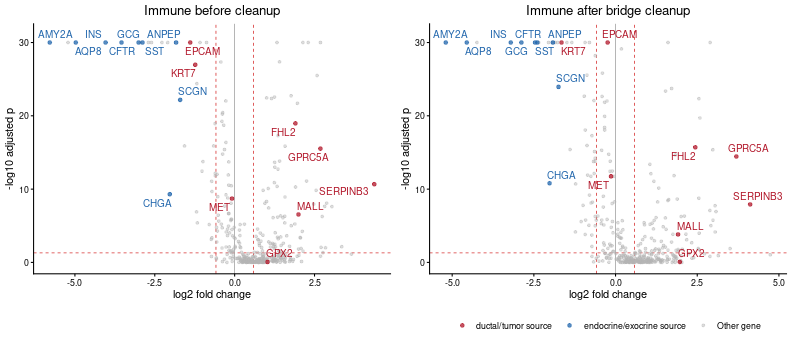

In [ ]:
for (target_type in diagnostic_cell_types) {
  p_before <- celladmix_plot_volcano(diagnostic_de_original[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "before cleanup")) +
    ggplot2::theme(legend.position = "none")
  p_after <- celladmix_plot_volcano(bridge_de[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "after bridge cleanup"))
  print(cowplot::plot_grid(plotlist = list(p_before, p_after),
    ncol = 2, align = "hv", axis = "tblr"))
}

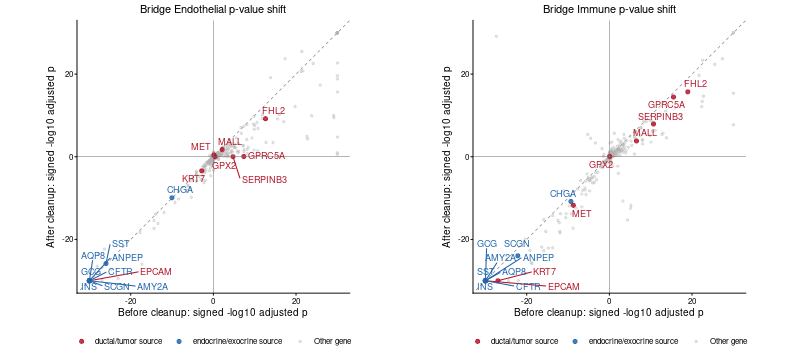

In [ ]:
plots <- lapply(diagnostic_cell_types, function(target_type) {
  celladmix_plot_de_shift(diagnostic_de_original[[target_type]], bridge_de[[target_type]],
    markers = source_marker_sets, title = paste("Bridge", target_type, "p-value shift"))
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

## Score Comparison

These summaries compare the source-cell annotation and target-cell
significance calls across membrane and bridge scoring. In each triangle
panel, the upper-right half of a cell corresponds to the first method
named in the subtitle and the lower-left half corresponds to the second.

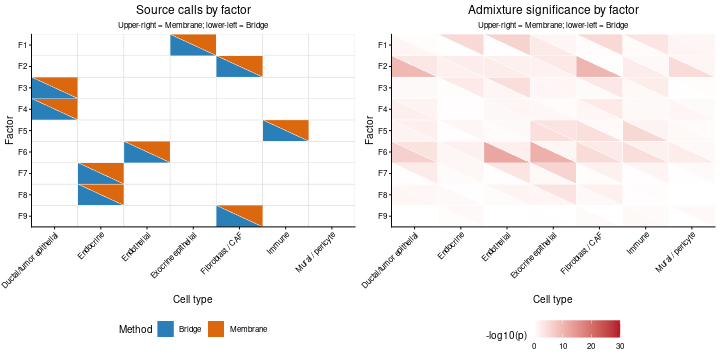

In [ ]:
celladmix_plot_score_agreement(list(Membrane = membrane_annotation,
  Bridge = bridge_annotation), p_thresh = p_thresh)